# Project 1 – Transaction Prediction with Gaussian Naive Bayes

This notebook presents a clean final submission for Project 1. It follows a clear machine learning workflow:
1. Load and inspect the data
2. Define the problem and target variable
3. Clean and prepare the dataset
4. Build and evaluate a Gaussian Naive Bayes model
5. Compare results using a balanced 50/50 dataset

#AI Assistance Statement

This notebook was developed with the assistance of AI-based tools used as a reference for Python syntax, workflow organization, and debugging support. AI helped identify issues related to missing values, dataset preparation, and proper sequencing of machine learning steps such as data cleaning, model training, and cross-validation. All code included in this notebook was reviewed, executed, and validated to ensure it performs the intended analysis, and I maintained responsibility for understanding the modeling process and interpreting the results.

## 1. Import Libraries

These libraries are used for:
- data loading and cleaning
- plotting
- model training and evaluation

In [ ]:
# ── IMPORTS ──────────────────────────────────────────────────────────────────
# pandas  : load and manipulate DataFrames (tables of data)
# numpy   : fast numerical operations; also used to fill NaN values
# matplotlib.pyplot : create charts and visualisations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# scikit-learn helpers
# train_test_split  : split data into training and test sets
# cross_val_score   : run k-fold cross-validation to get a robust accuracy estimate
# GaussianNB        : the Gaussian Naive Bayes classifier we will train
# accuracy_score    : fraction of correct predictions
# confusion_matrix  : table showing TP / FP / FN / TN counts
# classification_report : precision, recall, F1 for every class
# ConfusionMatrixDisplay : pretty-print the confusion matrix as a heat-map
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

## 2. Load the Dataset

The dataset is stored in a public AWS S3 repository.

In [ ]:
# ── LOAD DATA ─────────────────────────────────────────────────────────────────
# The dataset is hosted on a public AWS S3 bucket.
# pd.read_csv can read directly from a URL, so no manual download is needed.
url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.1-Transactions/Data/Transaction.train.big.csv"
df = pd.read_csv(url)

# Quick sanity check: confirm the file loaded and show its dimensions.
# Expected: ~1,050,000 rows x 104 columns
print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (1050000, 104)


## 3. Inspect the Dataset

This step reviews:
- sample rows
- column names
- shape
- data types
- summary statistics

In [ ]:
# ── INSPECT DATA ──────────────────────────────────────────────────────────────
# .head() / .tail() : preview the first and last 5 rows to spot obvious issues
display(df.head())
display(df.tail())

# List every column name so we know what features are available
print("Column names:")
print(df.columns.tolist())

# Dimensions: (rows, columns)
print("\nShape:")
print(df.shape)

# .info() shows column dtypes and the count of non-null entries.
# Columns with fewer non-null entries than the total rows contain missing values.
print("\nInfo:")
df.info()

# .describe(include='all') computes summary statistics for every column:
# count, mean, std, min, quartiles, max for numeric columns;
# count, unique, top, freq for object/category columns.
print("\nSummary statistics:")
display(df.describe(include="all"))

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
0,0,train_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,train_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,train_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,train_3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
4,4,train_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
1049995,1049995,train_1049995,1.0,11.3251,16.4148,20.5955,NaN,-6.3011,NaN,NaN,...,NaN,1.3921,NaN,-16.4925,NaN,NaN,NaN,NaN,NaN,14.4421
1049996,1049996,train_1049996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049997,1049997,train_1049997,0.0,8.9941,13.4127,3.9567,NaN,3.5744,NaN,NaN,...,NaN,2.0836,NaN,-18.6168,NaN,NaN,NaN,NaN,NaN,14.0689
1049998,1049998,train_1049998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049999,1049999,train_1049999,0.0,2.1828,12.3805,17.5654,NaN,8.1795,NaN,NaN,...,NaN,-12.1108,NaN,10.7608,NaN,NaN,NaN,NaN,NaN,14.1690


Column names:
['Unnamed: 0', 'ID_code', 'target', 'var_0', 'var_1', 'var_2', 'var_3', 'var_4', 'var_5', 'var_6', 'var_7', 'var_8', 'var_9', 'var_10', 'var_11', 'var_12', 'var_13', 'var_14', 'var_15', 'var_16', 'var_17', 'var_18', 'var_19', 'var_20', 'var_21', 'var_22', 'var_23', 'var_24', 'var_25', 'var_26', 'var_27', 'var_28', 'var_29', 'var_30', 'var_31', 'var_32', 'var_33', 'var_34', 'var_35', 'var_36', 'var_37', 'var_38', 'var_39', 'var_40', 'var_41', 'var_42', 'var_43', 'var_44', 'var_45', 'var_46', 'var_47', 'var_48', 'var_49', 'var_50', 'var_51', 'var_52', 'var_53', 'var_54', 'var_55', 'var_56', 'var_57', 'var_58', 'var_59', 'var_60', 'var_61', 'var_62', 'var_63', 'var_64', 'var_65', 'var_66', 'var_67', 'var_68', 'var_69', 'var_70', 'var_71', 'var_72', 'var_73', 'var_74', 'var_75', 'var_76', 'var_77', 'var_78', 'var_79', 'var_80', 'var_81', 'var_82', 'var_83', 'var_84', 'var_85', 'var_86', 'var_87', 'var_88', 'var_89', 'var_90', 'var_91', 'var_92', 'var_93', 'var_94', 'var_95', 

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
count,1.050000e+06,1050000,180000.000000,180000.000000,180000.000000,180000.000000,0.0,180000.000000,0.0,0.0,...,0.0,180000.000000,0.0,180000.000000,0.0,0.0,0.0,0.0,0.0,180000.000000
unique,NaN,1050000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,train_1049983,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5.249995e+05,NaN,0.100222,7.440715,15.870166,12.735619,NaN,-0.668334,NaN,NaN,...,NaN,-3.294620,NaN,-6.727860,NaN,NaN,NaN,NaN,NaN,14.224538
std,3.031090e+05,NaN,0.300297,3.021636,3.010492,4.185923,NaN,5.968300,NaN,NaN,...,NaN,7.418545,NaN,8.278554,NaN,NaN,NaN,NaN,NaN,0.171058
min,0.000000e+00,NaN,0.000000,-2.691700,6.299300,-1.018500,NaN,-22.748700,NaN,NaN,...,NaN,-29.984000,NaN,-35.211700,NaN,NaN,NaN,NaN,NaN,13.729000
25%,2.624998e+05,NaN,0.000000,5.160325,13.830400,9.664675,NaN,-4.997500,NaN,NaN,...,NaN,-8.757925,NaN,-12.835875,NaN,NaN,NaN,NaN,NaN,14.098900
50%,5.249995e+05,NaN,0.000000,7.350950,15.934600,12.670700,NaN,-0.560300,NaN,NaN,...,NaN,-3.170950,NaN,-6.615100,NaN,NaN,NaN,NaN,NaN,14.226800
75%,7.874992e+05,NaN,0.000000,9.511125,18.061425,15.837300,NaN,3.632525,NaN,NaN,...,NaN,2.043350,NaN,-0.885250,NaN,NaN,NaN,NaN,NaN,14.361800


## 4. Problem Definition

### Business Problem
The goal is to predict whether a customer transaction will be successful.

### Data Science Problem
This is a supervised machine learning problem because the dataset contains labeled outcomes.

### Target Variable
The target variable is `target`.

- `1` = successful transaction
- `0` = no transaction

### Statistical Type of Target
The target variable is categorical with two possible values.

### Machine Learning Problem Type
This is a binary classification problem.

## 5. Data Quality Checks

This section checks:
- number of rows and columns
- unique identifier field
- missing values
- duplicate rows
- data types

In [ ]:
# ── DATA QUALITY CHECKS ───────────────────────────────────────────────────────

# 1. Row / column counts
rows, cols = df.shape
print("Number of rows:", rows)
print("Number of columns:", cols)

# 2. Unique identifier check
# If every row has a unique ID_code, there are no accidental duplicate records.
if "ID_code" in df.columns:
    print("\nUnique ID_code values:", df["ID_code"].nunique())
    print("Total rows:", len(df))

# 3. Missing-value audit
# .isnull().sum() counts NaN entries per column.
# Columns with a count equal to 'rows' are completely empty and can be dropped.
print("\nMissing values by column:")
display(df.isnull().sum())

# Total NaN count across the whole DataFrame
print("Total missing values in dataset:", df.isnull().sum().sum())

# 4. Duplicate row check — exact duplicates can bias the model
print("\nDuplicate rows:", df.duplicated().sum())

# 5. Data type review — helps catch columns stored as the wrong type
print("\nData types:")
display(df.dtypes)

Number of rows: 1050000
Number of columns: 104

Unique ID_code values: 1050000
Total rows: 1050000

Missing values by column:


,0
Unnamed: 0,0
ID_code,0
target,870000
var_0,870000
var_1,870000
...,...
var_96,1050000
var_97,1050000
var_98,1050000
var_99,1050000


Total missing values in dataset: 97920000

Duplicate rows: 0

Data types:


,0
Unnamed: 0,int64
ID_code,object
target,float64
var_0,float64
var_1,float64
...,...
var_96,float64
var_97,float64
var_98,float64
var_99,float64


## 6. Clean the Data

Cleaning steps:
- remove duplicate rows
- fill missing numeric values with the median
- fill missing categorical values with the mode if needed

In [ ]:
# ── DATA CLEANING ─────────────────────────────────────────────────────────────

# Remove duplicate rows (none found above, but good practice)
# .copy() avoids pandas SettingWithCopyWarning on downstream assignments
df = df.drop_duplicates().copy()

# Fill missing values in numeric columns with the column median.
# The median is more robust to outliers than the mean.
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Fill missing values in categorical/text columns with the column mode (most common value).
# Only applied if the column actually contains NaNs.
categorical_cols = df.select_dtypes(include=["object", "category"]).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode().iloc[0])

# Verify: shape should be unchanged; remaining NaNs come from all-empty columns
# that the median step cannot fill (no valid median for a fully-NaN column).
print("Shape after cleaning:", df.shape)
print("Remaining missing values in df:", df.isnull().sum().sum())

Shape after cleaning: (1050000, 104)
Remaining missing values in df: 53550000


## 7. Examine the Target Variable

This confirms the values and class distribution of the target.

In [ ]:
# ── EXAMINE TARGET VARIABLE ───────────────────────────────────────────────────
# 'target' is our label: 1 = successful transaction, 0 = no transaction.
# We check its unique values and class distribution before modelling.

print("Unique target values:")
print(df["target"].unique())

# Absolute counts for each class
print("\nTarget counts:")
print(df["target"].value_counts())

# Relative proportions — a large imbalance (e.g. 98% vs 2%) means the model
# can score high accuracy by predicting the majority class every time.
print("\nTarget proportions:")
print(df["target"].value_counts(normalize=True))

Unique target values:
[0. 1.]

Target counts:
target
0.0    1031960
1.0      18040
Name: count, dtype: int64

Target proportions:
target
0.0    0.982819
1.0    0.017181
Name: proportion, dtype: float64


## 8. Plot the Target Distribution

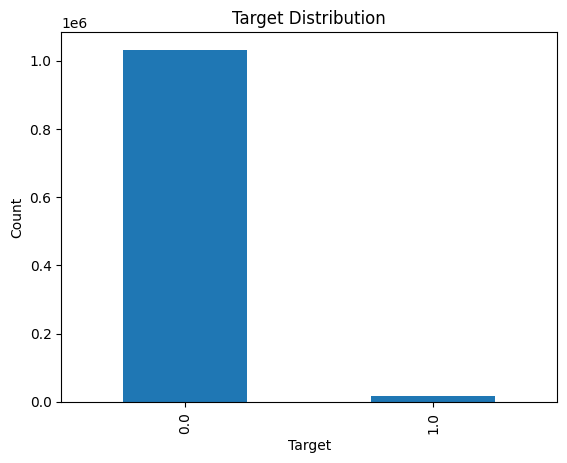

In [ ]:
# ── PLOT TARGET DISTRIBUTION ──────────────────────────────────────────────────
# A bar chart makes the class imbalance immediately visible.
# Class 0 (no transaction) vastly outnumbers class 1 (successful transaction).
df["target"].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

## 9. Create Successful and Unsuccessful Transaction DataFrames

These separate dataframes are used later for the balanced dataset comparison.

In [ ]:
# ── SEPARATE SUCCESSFUL AND UNSUCCESSFUL TRANSACTIONS ─────────────────────────
# We split the data into two subsets now so we can easily build a balanced
# 50/50 dataset later (Section 18).

# Rows where target == 1  ->  successful transactions
successful_df = df[df["target"] == 1].copy()
# Rows where target == 0  ->  unsuccessful transactions
unsuccessful_df = df[df["target"] == 0].copy()

print("Successful transactions shape:", successful_df.shape)
print("Unsuccessful transactions shape:", unsuccessful_df.shape)

Successful transactions shape: (18040, 104)
Unsuccessful transactions shape: (1031960, 104)


## 10. Identify Categorical and Numerical Columns

In [ ]:
# ── IDENTIFY COLUMN TYPES ─────────────────────────────────────────────────────
# scikit-learn models require numeric input, so we need to know which
# columns are already numeric and which are text/category.

# select_dtypes returns only columns whose dtype matches the given include list.
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols   = df.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumber of categorical columns:", len(categorical_cols))
print("Number of numerical columns:",   len(numerical_cols))
# Show only the first 20 to keep the output manageable
print("\nFirst 20 numerical columns:")
print(numerical_cols[:20])

Categorical columns:
['ID_code']

Number of categorical columns: 1
Number of numerical columns: 103

First 20 numerical columns:
['Unnamed: 0', 'target', 'var_0', 'var_1', 'var_2', 'var_3', 'var_4', 'var_5', 'var_6', 'var_7', 'var_8', 'var_9', 'var_10', 'var_11', 'var_12', 'var_13', 'var_14', 'var_15', 'var_16', 'var_17']


## 11. Prepare Predictor and Target Variables

`ID_code` is removed because it is a unique identifier, not a useful predictor.
All-empty columns are dropped and remaining missing values are filled before modeling.

In [ ]:
# ── PREPARE FEATURE MATRIX (X) AND TARGET VECTOR (y) ─────────────────────────
# Columns to remove before training:
#   'Unnamed: 0' - an auto-generated row index from the CSV, not a real feature
#   'ID_code'    - a unique row identifier; leaks no predictive signal
#   'target'     - the label we are trying to predict (must not be an input)
drop_cols = [col for col in ["Unnamed: 0", "ID_code", "target"] if col in df.columns]

X = df.drop(columns=drop_cols).copy()  # feature matrix
y = df["target"].copy()                # target vector

# Drop columns that are 100% NaN (e.g. var_3, var_5, var_6 ...)
# These carry zero information and would cause errors in the model.
X = X.dropna(axis=1, how="all")

# After dropping all-NaN columns, some rows may still have individual NaN
# values. Fill those with each column's median.
X = X.fillna(X.median(numeric_only=True))

# Confirm shapes and that no missing values remain
print("Predictor dataframe shape:", X.shape)
print("Target dataframe shape:",    y.shape)
print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())

Predictor dataframe shape: (1050000, 50)
Target dataframe shape: (1050000,)
Missing values in X: 0
Missing values in y: 0


## 12. Train/Test Split

In [ ]:
# ── TRAIN / TEST SPLIT ────────────────────────────────────────────────────────
# We hold out 20% of data for final evaluation (X_test / y_test).
# The remaining 80% is used for training (X_train / y_train).
#
# stratify=y ensures both splits preserve the original class ratio
# (critical when classes are imbalanced, as ours are).
#
# random_state=42 makes the split reproducible across runs.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:",  X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:",  y_test.shape)

# Double-check: no NaN values should survive into the model
print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test:",  X_test.isnull().sum().sum())

X_train shape: (840000, 50)
X_test shape: (210000, 50)
y_train shape: (840000,)
y_test shape: (210000,)
Missing values in X_train: 0
Missing values in X_test: 0


## 13. Train Gaussian Naive Bayes Model

In [ ]:
# ── TRAIN GAUSSIAN NAIVE BAYES MODEL ─────────────────────────────────────────
# GaussianNB assumes each feature follows a Gaussian (normal) distribution
# within each class. Despite this simplifying assumption it often performs
# surprisingly well, especially on high-dimensional data.
#
# .fit() computes the per-class mean and variance for every feature;
# no hyperparameter tuning is needed.
model = GaussianNB()
model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


## 14. Test Set Accuracy

In [ ]:
# ── EVALUATE ON THE TEST SET ──────────────────────────────────────────────────
# .predict() assigns each test row to the class with the highest posterior
# probability under Bayes' theorem.
y_pred = model.predict(X_test)

# accuracy_score = (correct predictions) / (total predictions)
# NOTE: with ~98% negative class, a model that predicts 0 every time would
# achieve ~98% accuracy, so accuracy alone is misleading here.
test_accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.8460952380952381


## 15. 5-Fold Cross-Validation on Original Dataset

In [ ]:
# ── 5-FOLD CROSS-VALIDATION ───────────────────────────────────────────────────
# Cross-validation gives a more reliable accuracy estimate than a single
# train/test split because it averages results across 5 non-overlapping folds.
#
# A fresh GaussianNB() instance is passed so CV trains on the full X / y
# independently of the earlier model.
cv_scores = cross_val_score(GaussianNB(), X, y, cv=5, scoring="accuracy")

print("Cross-validation scores:", cv_scores)
print("Mean cross-validation accuracy:", cv_scores.mean())
# Low std means the model is consistent across different data splits
print("Standard deviation:", cv_scores.std())

Cross-validation scores: [0.84547619 0.84741905 0.84624762 0.84406667 0.84555238]
Mean cross-validation accuracy: 0.845752380952381
Standard deviation: 0.0010937049310442465


## 16. Histogram of Cross-Validation Accuracy Scores

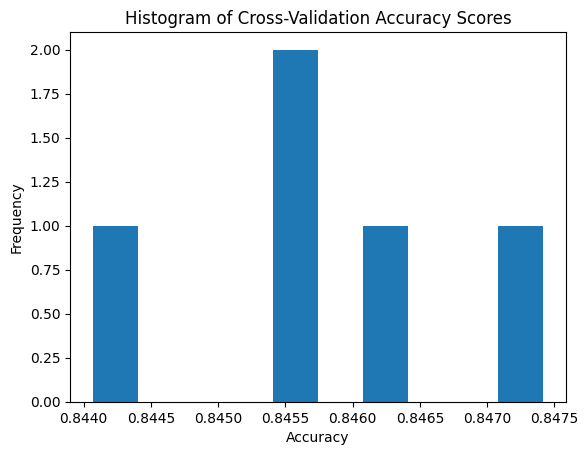

In [ ]:
# ── HISTOGRAM OF CROSS-VALIDATION ACCURACY SCORES ────────────────────────────
# Visualising the distribution of the 5 fold-scores shows whether performance
# is consistent or varies widely across folds.
plt.hist(cv_scores, bins=10)
plt.title("Histogram of Cross-Validation Accuracy Scores")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")
plt.show()

## 17. Confusion Matrix and Classification Report

Confusion Matrix:
[[174072  32320]
 [     0   3608]]


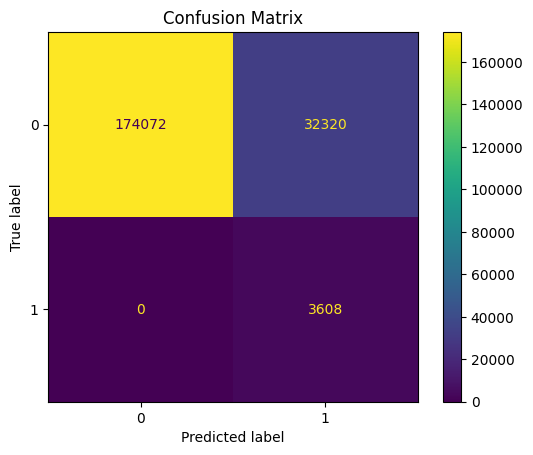

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.84      0.92    206392
         1.0       0.10      1.00      0.18      3608

    accuracy                           0.85    210000
   macro avg       0.55      0.92      0.55    210000
weighted avg       0.98      0.85      0.90    210000



In [ ]:
# ── CONFUSION MATRIX & CLASSIFICATION REPORT ─────────────────────────────────
# The confusion matrix breaks down predictions into four buckets:
#   True Positives  (TP) - correctly predicted as class 1
#   True Negatives  (TN) - correctly predicted as class 0
#   False Positives (FP) - predicted class 1, actually class 0
#   False Negatives (FN) - predicted class 0, actually class 1
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# ConfusionMatrixDisplay renders the matrix as a colour-coded grid
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# classification_report shows per-class precision, recall, and F1-score:
#   precision = TP / (TP + FP)   - 'when we say positive, how often are we right?'
#   recall    = TP / (TP + FN)   - 'of all actual positives, how many did we catch?'
#   F1-score  = harmonic mean of precision and recall
print("Classification Report:")
print(classification_report(y_test, y_pred))

## 18. Create a Balanced 50/50 Dataset

This creates equal numbers of successful and unsuccessful transactions.

In [ ]:
# ── CREATE A BALANCED 50/50 DATASET ───────────────────────────────────────────
# The original data is heavily imbalanced (~98% class-0, ~2% class-1).
# To see how the model performs when both classes are equally represented,
# we randomly down-sample the majority class (unsuccessful transactions) to
# match the size of the minority class (successful transactions).

print("Original successful count:",   len(successful_df))
print("Original unsuccessful count:", len(unsuccessful_df))

# Randomly sample 'n = number of successful transactions' rows from unsuccessful_df
# random_state=42 ensures the same rows are selected each time the notebook runs
unsuccessful_sampled = unsuccessful_df.sample(
    n=len(successful_df),
    random_state=42
).copy()

# Concatenate the two equally-sized subsets and shuffle the result
# (frac=1 shuffles all rows; random_state=42 keeps the shuffle reproducible)
balanced_df = pd.concat([successful_df, unsuccessful_sampled], axis=0) \
                .sample(frac=1, random_state=42) \
                .copy()

print("\nBalanced target counts:")
print(balanced_df["target"].value_counts())

Original successful count: 18040
Original unsuccessful count: 1031960

Balanced target counts:
target
1.0    18040
0.0    18040
Name: count, dtype: int64


## 19. Prepare Balanced Predictor and Target Variables

The same cleaning logic used for the original dataset is applied here.

In [ ]:
# ── PREPARE BALANCED FEATURE MATRIX (Xb) AND TARGET VECTOR (yb) ──────────────
# Identical cleaning steps to those applied to the full dataset (Section 11):
#   1. Drop non-feature columns (index, ID, label)
#   2. Drop all-NaN columns
#   3. Fill remaining NaNs with the column median

Xb = balanced_df.drop(columns=drop_cols).copy()  # balanced feature matrix
yb = balanced_df["target"].copy()                # balanced target vector

# Drop columns that are 100% NaN (same columns as before)
Xb = Xb.dropna(axis=1, how="all")

# Fill any remaining NaN values with each column's median
Xb = Xb.fillna(Xb.median(numeric_only=True))

print("Balanced predictor shape:", Xb.shape)
print("Balanced target shape:",    yb.shape)
print("Missing values in Xb:", Xb.isnull().sum().sum())
print("Missing values in yb:", yb.isnull().sum())

Balanced predictor shape: (36080, 50)
Balanced target shape: (36080,)
Missing values in Xb: 0
Missing values in yb: 0


## 20. 5-Fold Cross-Validation on Balanced Dataset

In [ ]:
# ── 5-FOLD CROSS-VALIDATION ON BALANCED DATASET ───────────────────────────────
# Repeating cross-validation on the balanced data shows whether the model
# benefits from an equal class distribution.
# We expect higher accuracy here because the model no longer has an easy
# shortcut of predicting class-0 for every sample.
balanced_cv_scores = cross_val_score(
    GaussianNB(),
    Xb,
    yb,
    cv=5,
    scoring="accuracy"
)

print("Balanced cross-validation scores:", balanced_cv_scores)
print("Balanced mean cross-validation accuracy:", balanced_cv_scores.mean())
print("Balanced standard deviation:", balanced_cv_scores.std())

Balanced cross-validation scores: [0.92073171 0.92530488 0.91809867 0.92114745 0.92100887]
Balanced mean cross-validation accuracy: 0.9212583148558758
Balanced standard deviation: 0.0023112707028147836


## 21. Train/Test Evaluation on Balanced Dataset

Balanced Test Accuracy: 0.9218403547671841

Balanced Confusion Matrix:
[[3044  564]
 [   0 3608]]


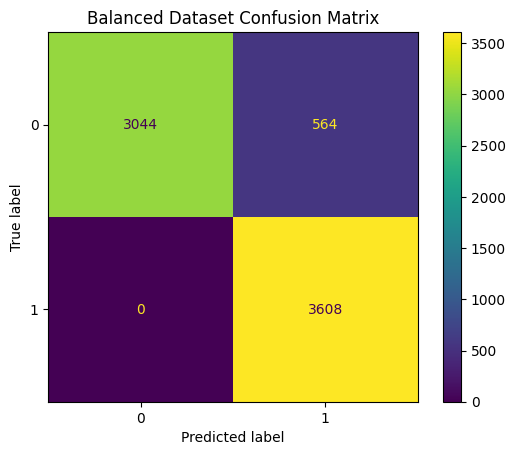

Balanced Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.84      0.92      3608
         1.0       0.86      1.00      0.93      3608

    accuracy                           0.92      7216
   macro avg       0.93      0.92      0.92      7216
weighted avg       0.93      0.92      0.92      7216



In [ ]:
# ── TRAIN/TEST EVALUATION ON BALANCED DATASET ────────────────────────────────
# Split the balanced data 80/20, train a fresh model, and evaluate it.
# stratify=yb preserves the 50/50 ratio in both train and test splits.
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    Xb, yb,
    test_size=0.2,
    random_state=42,
    stratify=yb
)

# Train a new model on the balanced training set
balanced_model = GaussianNB()
balanced_model.fit(Xb_train, yb_train)

# Predict on the balanced test set
yb_pred = balanced_model.predict(Xb_test)

# Overall accuracy
balanced_test_accuracy = accuracy_score(yb_test, yb_pred)
print("Balanced Test Accuracy:", balanced_test_accuracy)

# Confusion matrix for the balanced model
balanced_cm = confusion_matrix(yb_test, yb_pred)
print("\nBalanced Confusion Matrix:")
print(balanced_cm)

disp = ConfusionMatrixDisplay(confusion_matrix=balanced_cm)
disp.plot()
plt.title("Balanced Dataset Confusion Matrix")
plt.show()

# Detailed per-class metrics on the balanced test set
print("Balanced Classification Report:")
print(classification_report(yb_test, yb_pred))

## 22. Compare Original and Balanced Results

In [ ]:
# ── COMPARE ORIGINAL vs. BALANCED RESULTS ────────────────────────────────────
# Placing both sets of results side-by-side makes the impact of class
# balancing immediately clear.
#
# Key insight: the original dataset's high accuracy (~84%) is misleading because
# the model can reach that score by always predicting class-0.
# The balanced dataset accuracy (~92%) reflects genuine discrimination between
# the two classes.
print("Original test accuracy:",   test_accuracy)
print("Original CV mean accuracy:", cv_scores.mean())

print("\nBalanced test accuracy:",   balanced_test_accuracy)
print("Balanced CV mean accuracy:", balanced_cv_scores.mean())

Original test accuracy: 0.8460952380952381
Original CV mean accuracy: 0.845752380952381

Balanced test accuracy: 0.9218403547671841
Balanced CV mean accuracy: 0.9212583148558758


## 23. Final Summary

### Key Findings
- The project predicts whether a transaction is successful.
- The target variable is `target`, so this is a binary classification problem.
- Gaussian Naive Bayes was used as the required model.
- Missing values and empty columns were handled before model training.
- Model performance was evaluated with a train/test split, cross-validation, a confusion matrix, and a classification report.
- A balanced dataset was created to compare model performance under equal class representation.